# Decay Mode Multiclass Classification Analysis
Analysis of ParticleTransformer decay mode multiclass classification results

In [1]:
import os
import numpy as np
import pandas as pd
import awkward as ak
import matplotlib.pyplot as plt
import mplhep as hep
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, precision_score, recall_score, accuracy_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import json
import enreg.tools.general as g

hep.style.use("CMS")
%matplotlib inline

## Load Data

In [2]:
model_path = "/user/u/urrejola/TauFCC/ml-tau-en-reg/training-outputs/dm_multiclass/dm_multiclass/ParticleTransformer"
model_path = "/user/u/urrejola/TauFCC/ml-tau-en-reg/training-outputs/dm_multiclass_epoch10/dm_multiclass/ParticleTransformer"


In [4]:
# Load test data
zh_test_path = os.path.join(model_path, "zh_test.parquet")
z_test_path = os.path.join(model_path, "z_test.parquet")
qq_test_path = os.path.join(model_path, "qq_test.parquet")

# Load and extract dm_multiclass data
zh_full = ak.from_parquet(zh_test_path)
z_full = ak.from_parquet(z_test_path)
qq_full = ak.from_parquet(qq_test_path)

In [5]:
print("ZH fields:", zh_full.fields)
print("\nLoading dm_multiclass data...")

# Access dm_multiclass - convert to list if needed
zh_test = zh_full["dm_multiclass"]
z_test = z_full["dm_multiclass"]
qq_test = qq_full["dm_multiclass"]



ZH fields: ['dm_multiclass']

Loading dm_multiclass data...


In [6]:
type(zh_test)


awkward.highlevel.Record

In [7]:
zh_test.fields

['pred', 'target']

In [8]:
len(zh_test["pred"])

1042833

In [9]:
len(zh_test["target"])


1042833

In [10]:
print(f"ZH test set size: {len(zh_test['pred'])}")
print(f"Z test set size: {len(z_test['pred'])}")
print(f"QQ test set size: {len(qq_test['pred'])}")

ZH test set size: 1042833
Z test set size: 839828
QQ test set size: 1902388


## Inspect Data Structure

In [11]:
print("ZH test type:", type(zh_test))
print("ZH test fields:", zh_test.fields if hasattr(zh_test, 'fields') else "N/A")

if hasattr(zh_test, '__len__'):
    print(f"\nZH test target (first 20):", zh_test.target[:20])
    print("ZH test pred shape:", np.array(zh_test.pred).shape)
    print("ZH test pred (first 5):", zh_test.pred[:5])
    
    # Check unique classes
    print(f"\nUnique target classes in zh_test: {np.unique(ak.to_numpy(zh_test.target))}")
    print(f"Unique target classes in z_test: {np.unique(ak.to_numpy(z_test.target))}")
    print(f"Unique target classes in qq_test: {np.unique(ak.to_numpy(qq_test.target))}")
else:
    print("Cannot access length - checking structure...")

ZH test type: <class 'awkward.highlevel.Record'>
ZH test fields: ['pred', 'target']
Cannot access length - checking structure...


## Convert to NumPy and Get Predictions

In [12]:
zh_pred_proba.shape
zh_pred_proba[:10]


NameError: name 'zh_pred_proba' is not defined

In [21]:
# Convert to numpy
zh_target = ak.to_numpy(zh_test.target)
zh_pred_proba = ak.to_numpy(zh_test.pred)
zh_pred = zh_pred_proba  # already class labels

z_target = ak.to_numpy(z_test.target)
z_pred_proba = ak.to_numpy(z_test.pred)
z_pred = z_pred_proba  # already class labels

qq_target = ak.to_numpy(qq_test.target)
qq_pred_proba = ak.to_numpy(qq_test.pred)
qq_pred = qq_pred_proba  # already class labels

print(f"ZH: shape={zh_pred.shape}, n_classes={len(np.unique(zh_target))}")
print(f"Z: shape={z_pred.shape}, n_classes={len(np.unique(z_target))}")
print(f"QQ: shape={qq_pred.shape}, n_classes={len(np.unique(qq_target))}")

ZH: shape=(1042833,), n_classes=6
Z: shape=(839828,), n_classes=6
QQ: shape=(1902388,), n_classes=1


## Class Distribution

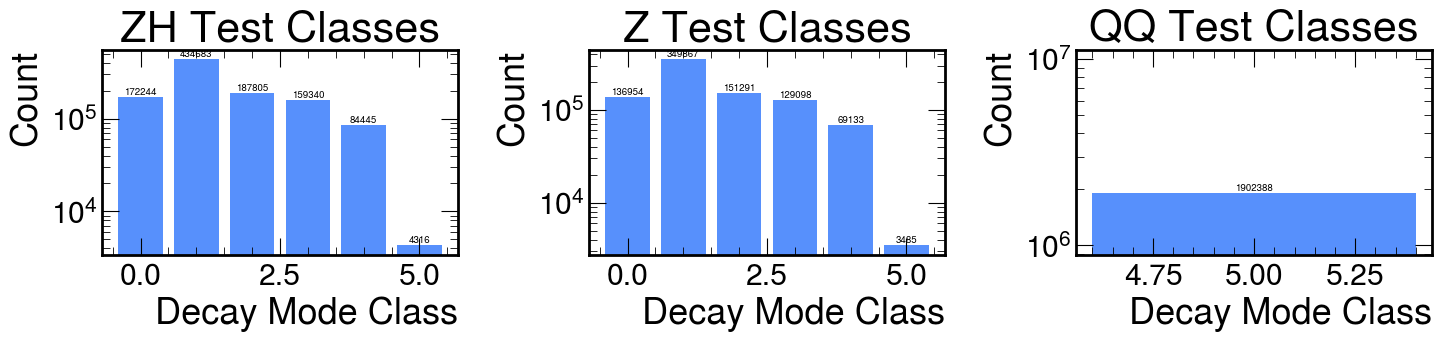

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, target, name in [(axes[0], zh_target, "ZH"), 
                          (axes[1], z_target, "Z"), 
                          (axes[2], qq_target, "QQ")]:
    unique, counts = np.unique(target, return_counts=True)
    ax.bar(unique, counts)
    ax.set_xlabel("Decay Mode Class")
    ax.set_ylabel("Count")
    ax.set_title(f"{name} Test Classes")
    ax.set_yscale("log")
    for i, c in zip(unique, counts):
        ax.text(i, c, str(c), ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

## Global Metrics

In [16]:
def compute_metrics(y_true, y_pred, y_pred_proba, dataset_name):
    """Compute comprehensive metrics for multiclass classification"""
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    
    print(f"\n{'='*60}")
    print(f"{dataset_name} Test Set Metrics")
    print(f"{'='*60}")
    print(f"Accuracy (overall):        {acc:.4f}")
    print(f"F1 Score (macro avg):      {f1_macro:.4f}")
    print(f"F1 Score (weighted avg):   {f1_weighted:.4f}")
    print(f"Precision (macro avg):     {precision_macro:.4f}")
    print(f"Recall (macro avg):        {recall_macro:.4f}")
    print(f"Number of samples:         {len(y_true)}")
    print(f"Number of classes:         {len(np.unique(y_true))}")
    
    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro
    }

metrics_zh = compute_metrics(zh_target, zh_pred, zh_pred_proba, "ZH")
metrics_z = compute_metrics(z_target, z_pred, z_pred_proba, "Z")
metrics_qq = compute_metrics(qq_target, qq_pred, qq_pred_proba, "QQ")


ZH Test Set Metrics
Accuracy (overall):        0.8277
F1 Score (macro avg):      0.7207
F1 Score (weighted avg):   0.8538
Precision (macro avg):     0.7406
Recall (macro avg):        0.7456
Number of samples:         1042833
Number of classes:         6

Z Test Set Metrics
Accuracy (overall):        0.8366
F1 Score (macro avg):      0.7195
F1 Score (weighted avg):   0.8520
Precision (macro avg):     0.7289
Recall (macro avg):        0.7431
Number of samples:         839828
Number of classes:         6

QQ Test Set Metrics
Accuracy (overall):        0.9584
F1 Score (macro avg):      0.1631
F1 Score (weighted avg):   0.9788
Precision (macro avg):     0.1667
Recall (macro avg):        0.1597
Number of samples:         1902388
Number of classes:         1


## Per-Class Metrics

In [17]:
def print_per_class_metrics(y_true, y_pred, dataset_name):
    """Print detailed per-class metrics"""
    print(f"\n{'='*80}")
    print(f"{dataset_name} - Per-Class Metrics")
    print(f"{'='*80}")
    print(classification_report(y_true, y_pred, zero_division=0))

print_per_class_metrics(zh_target, zh_pred, "ZH")
print_per_class_metrics(z_target, z_pred, "Z")
print_per_class_metrics(qq_target, qq_pred, "QQ")


ZH - Per-Class Metrics
              precision    recall  f1-score   support

           0       0.94      0.90      0.92    172244
           1       0.92      0.80      0.86    434683
           2       0.73      0.82      0.77    187805
           3       0.95      0.87      0.91    159340
           4       0.89      0.78      0.83     84445
           5       0.02      0.29      0.04      4316

    accuracy                           0.83   1042833
   macro avg       0.74      0.75      0.72   1042833
weighted avg       0.89      0.83      0.85   1042833


Z - Per-Class Metrics
              precision    recall  f1-score   support

           0       0.93      0.92      0.93    136954
           1       0.91      0.81      0.86    349867
           2       0.71      0.83      0.76    151291
           3       0.93      0.88      0.91    129098
           4       0.87      0.77      0.82     69133
           5       0.03      0.24      0.05      3485

    accuracy                  

## Confusion Matrices

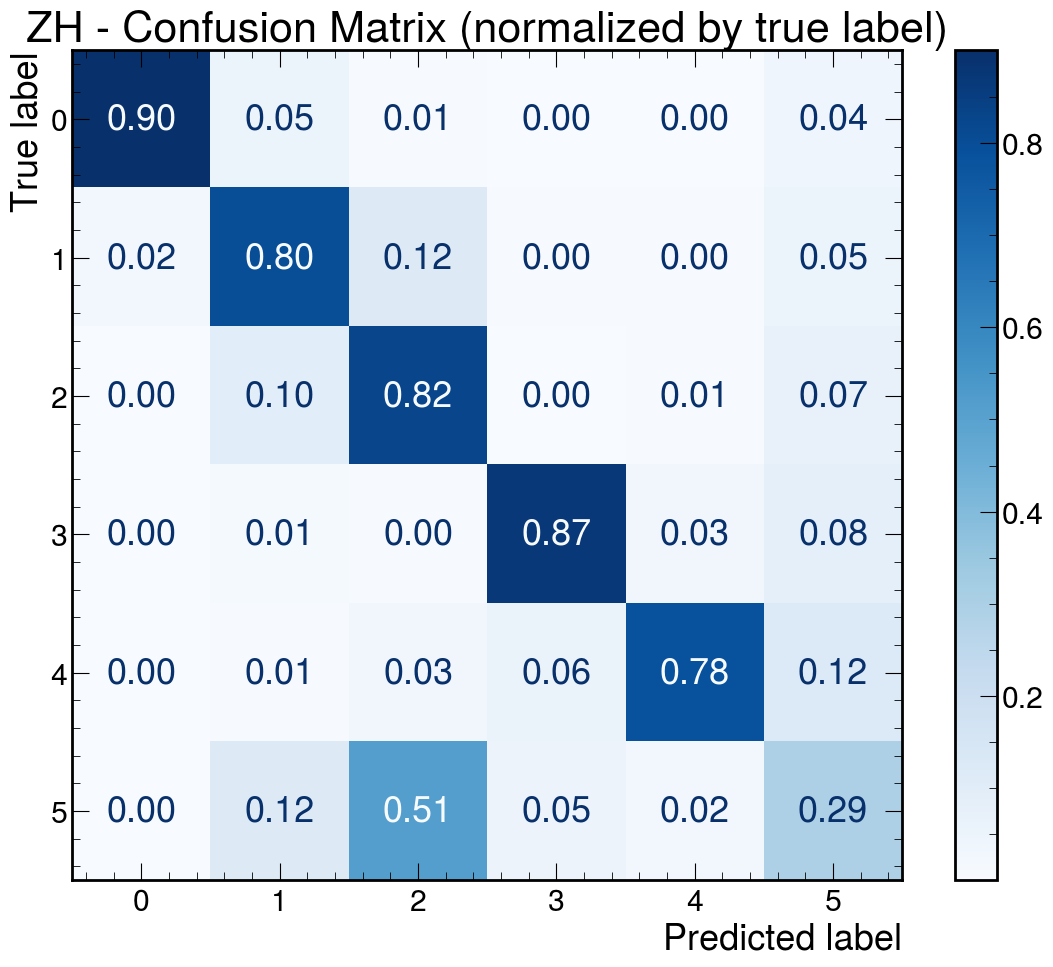

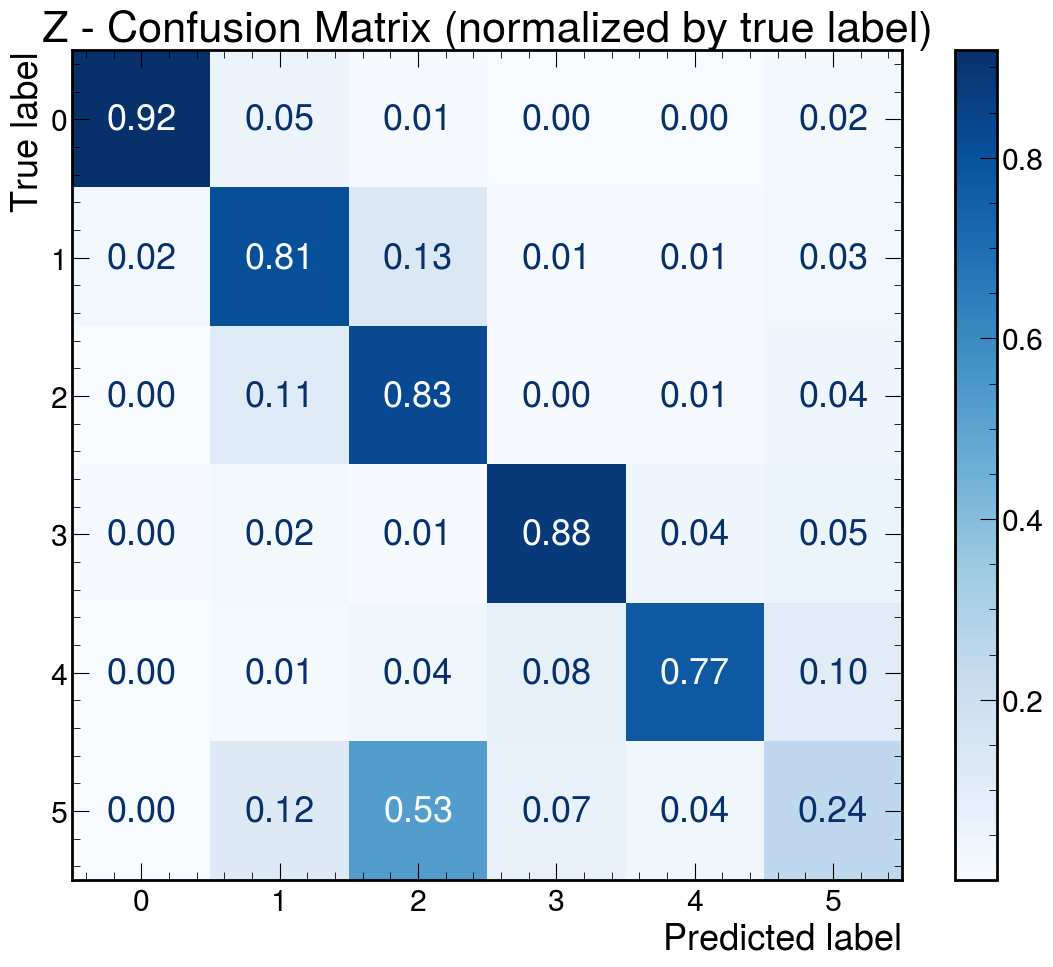

/tmp/ipykernel_806717/939955607.py:4: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


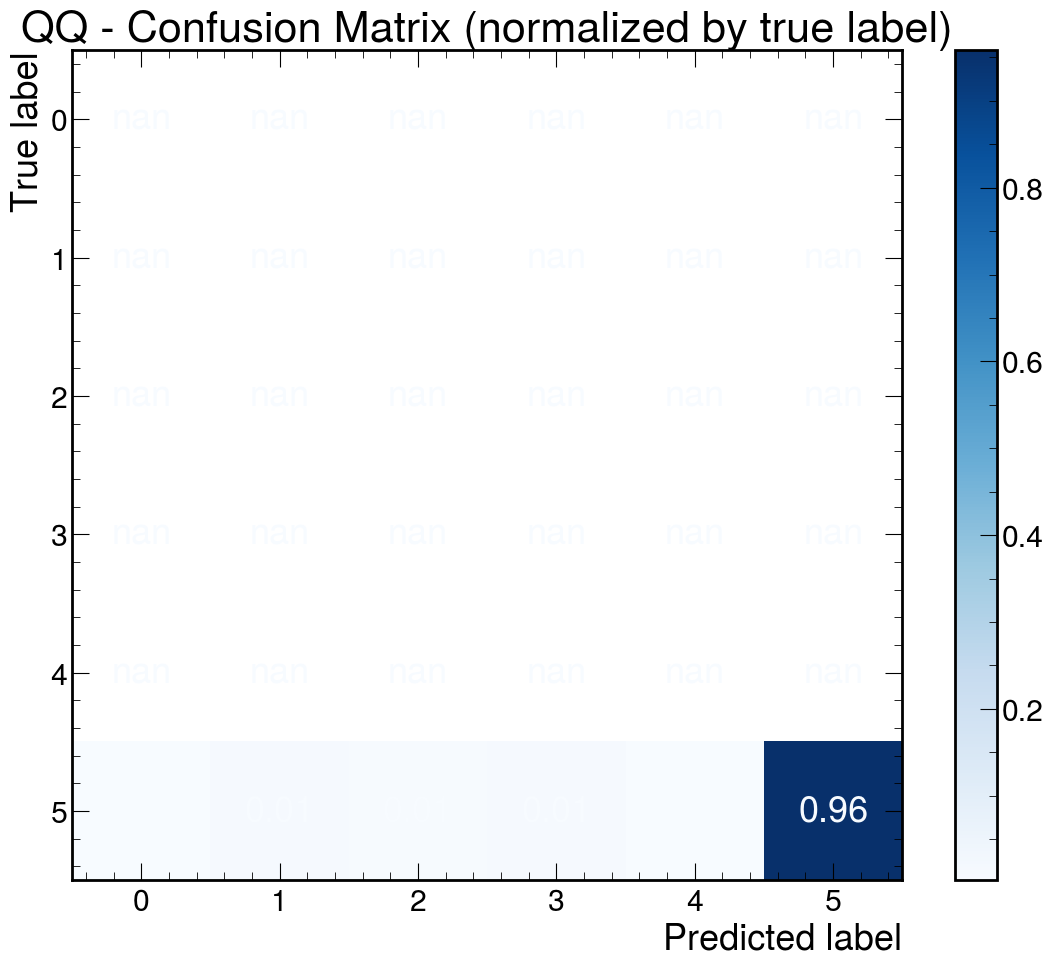

In [18]:
def plot_confusion_matrix(y_true, y_pred, dataset_name, figsize=(12, 10)):
    """Plot normalized confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, ax = plt.subplots(figsize=figsize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=None)
    disp.plot(ax=ax, cmap='Blues', values_format='.2f')
    ax.set_title(f"{dataset_name} - Confusion Matrix (normalized by true label)")
    plt.tight_layout()
    plt.show()
    
    return cm, cm_normalized

cm_zh, cm_zh_norm = plot_confusion_matrix(zh_target, zh_pred, "ZH")
cm_z, cm_z_norm = plot_confusion_matrix(z_target, z_pred, "Z")
cm_qq, cm_qq_norm = plot_confusion_matrix(qq_target, qq_pred, "QQ")

In [24]:
print(zh_pred_proba.shape)


(1042833,)


## Prediction Confidence Distribution

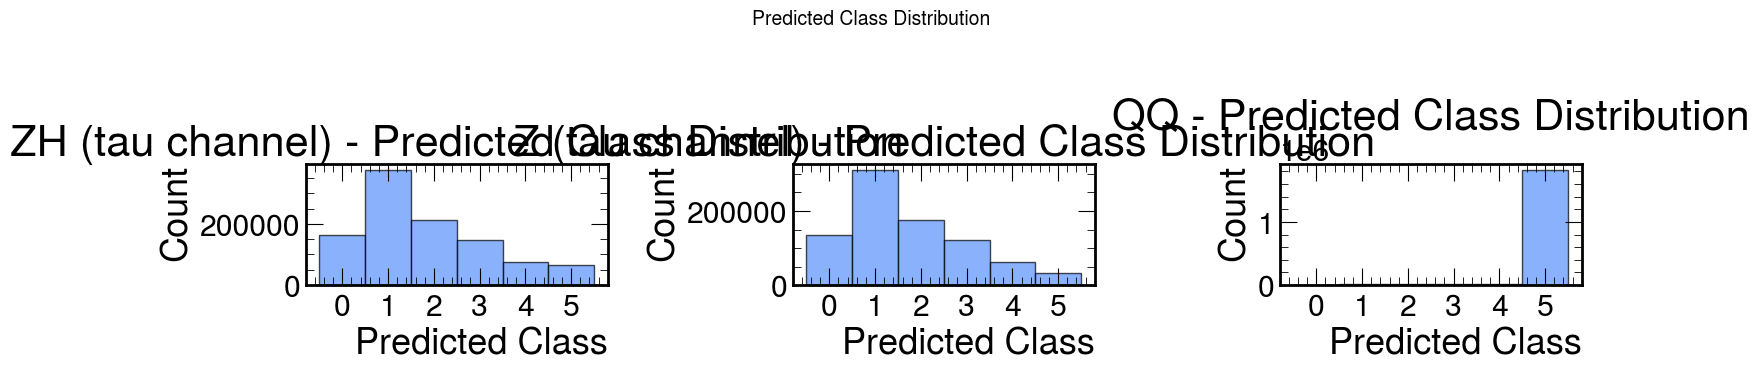

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, preds, name in [
    (axes[0], zh_pred_proba, "ZH (tau channel)"),
    (axes[1], z_pred_proba, "Z (tau channel)"),
    (axes[2], qq_pred_proba, "QQ")
]:
    ax.hist(preds, bins=np.arange(-0.5, 6.5, 1), edgecolor='black', alpha=0.7)
    ax.set_xticks(range(6))
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Count")
    ax.set_title(f"{name} - Predicted Class Distribution")

plt.suptitle("Predicted Class Distribution", fontsize=14)
plt.tight_layout()
plt.show()

## Accuracy vs Confidence

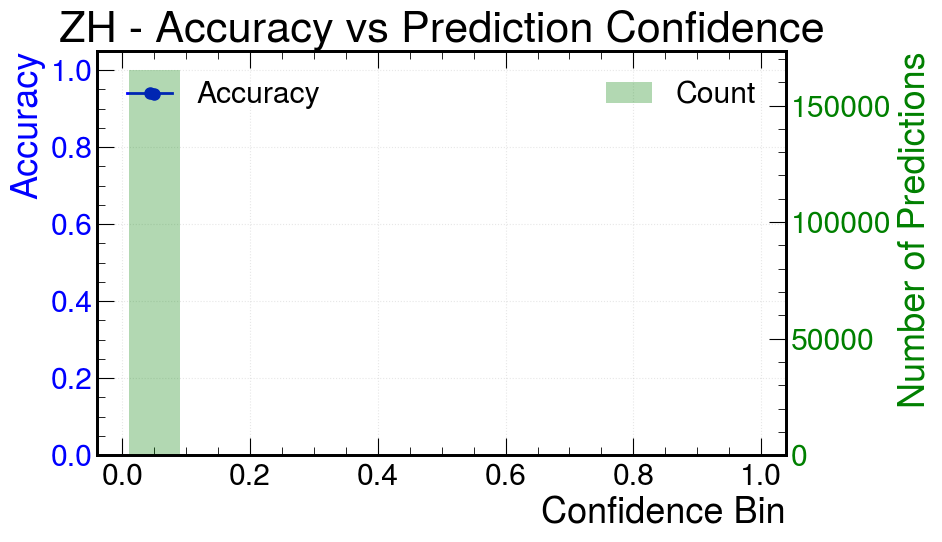

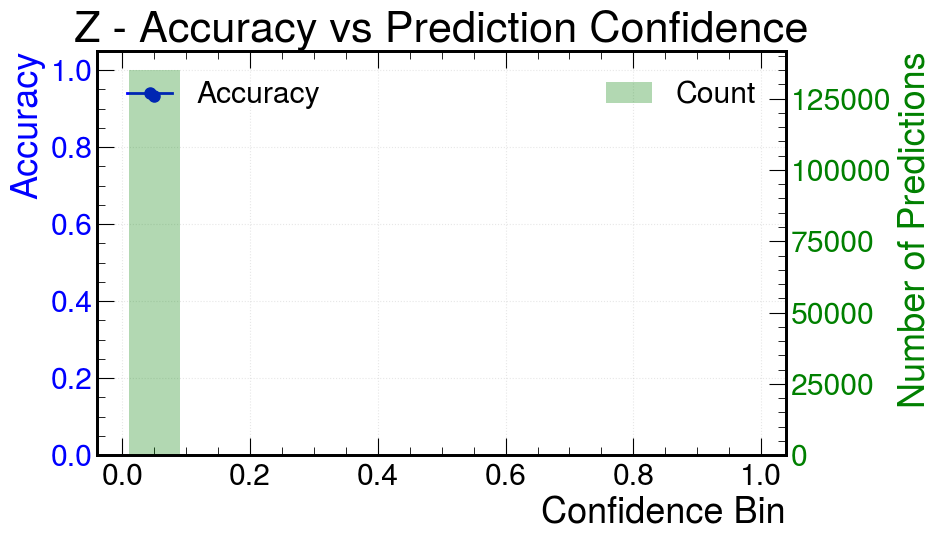

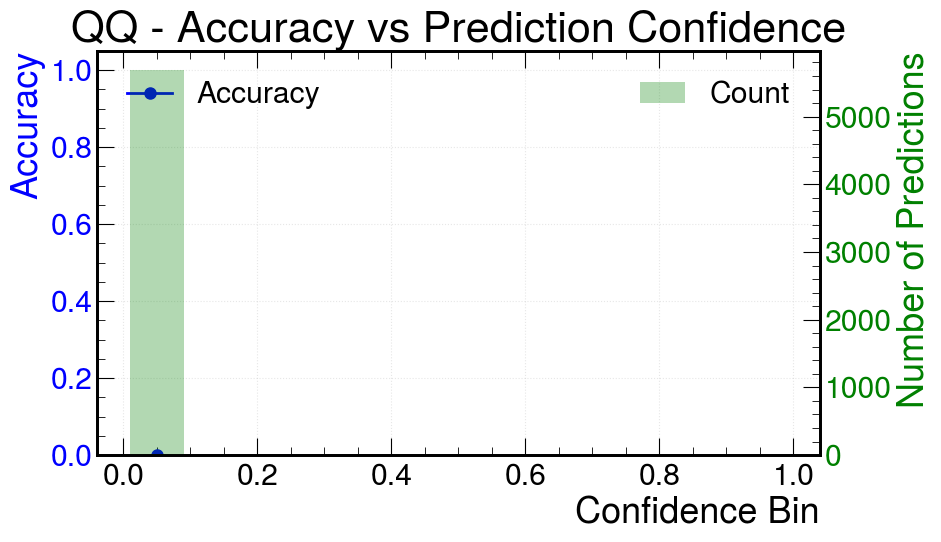

In [28]:
def plot_accuracy_vs_confidence(y_true, y_pred, confidence, dataset_name, n_bins=10):
    """Plot accuracy as a function of prediction confidence"""
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    accuracies = []
    counts = []
    
    for i in range(len(bins) - 1):
        mask = (confidence >= bins[i]) & (confidence < bins[i + 1])
        if mask.sum() > 0:
            acc = accuracy_score(y_true[mask], y_pred[mask])
            accuracies.append(acc)
            counts.append(mask.sum())
        else:
            accuracies.append(np.nan)
            counts.append(0)
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(bin_centers, accuracies, 'o-', linewidth=2, markersize=8, label='Accuracy', color='blue')
    ax1.set_xlabel('Confidence Bin')
    ax1.set_ylabel('Accuracy', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_ylim([0, 1.05])
    ax1.grid(True, alpha=0.3)
    
    ax2 = ax1.twinx()
    ax2.bar(bin_centers, counts, width=0.08, alpha=0.3, label='Count', color='green')
    ax2.set_ylabel('Number of Predictions', color='green')
    ax2.tick_params(axis='y', labelcolor='green')
    
    ax1.set_title(f"{dataset_name} - Accuracy vs Prediction Confidence")
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

plot_accuracy_vs_confidence(zh_target, zh_pred, zh_confidence, "ZH")
plot_accuracy_vs_confidence(z_target, z_pred, z_confidence, "Z")
plot_accuracy_vs_confidence(qq_target, qq_pred, qq_confidence, "QQ")

## ROC Curves (One-vs-Rest)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

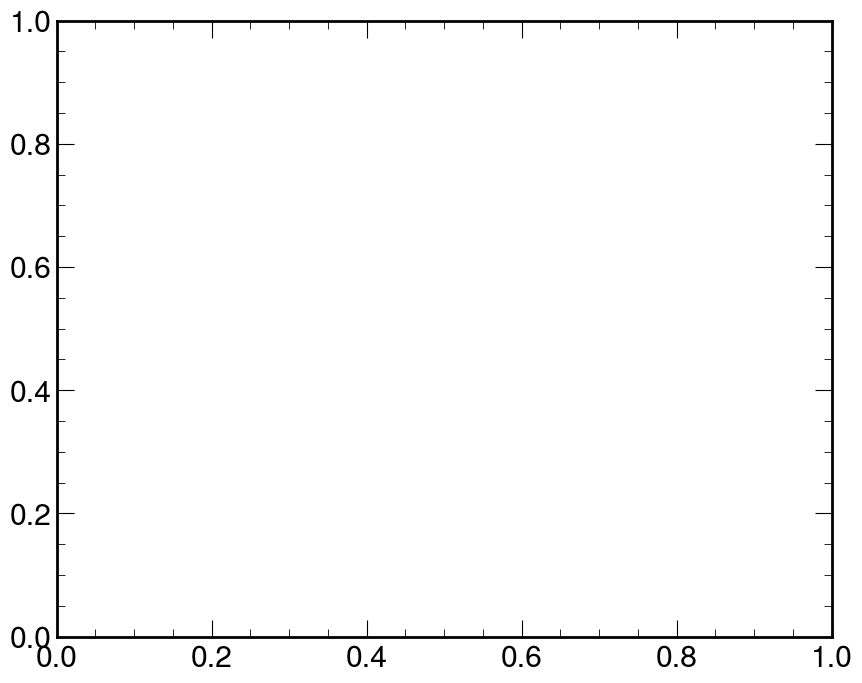

In [29]:
def plot_roc_curves(y_true, y_pred_proba, dataset_name, n_classes=None):
    """Plot ROC curves for each class (One-vs-Rest)"""
    if n_classes is None:
        n_classes = len(np.unique(y_true))
    
    y_bin = label_binarize(y_true, classes=np.arange(n_classes))
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for i in range(n_classes):
        if np.sum(y_bin[:, i]) == 0:
            continue  # Skip classes with no samples
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.3f})', linewidth=2)
    
    ax.plot([0, 1], [0, 1], 'k--', label='Chance', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f"{dataset_name} - ROC Curves (One-vs-Rest)")
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_roc_curves(zh_target, zh_pred_proba, "ZH")
plot_roc_curves(z_target, z_pred_proba, "Z")
plot_roc_curves(qq_target, qq_pred_proba, "QQ")

## Misclassification Analysis

In [32]:
def analyze_misclassifications(y_true, y_pred, confidence, dataset_name):
    """Analyze misclassified examples"""
    misclass_mask = y_true != y_pred
    n_misclass = misclass_mask.sum()
    n_total = len(y_true)
    error_rate = n_misclass / n_total
    
    print(f"\n{'='*60}")
    print(f"{dataset_name} - Misclassification Analysis")
    print(f"{'='*60}")
    print(f"Total misclassifications: {n_misclass} / {n_total} ({error_rate*100:.2f}%)")
    print(f"Mean confidence of correct predictions: {np.mean(confidence[~misclass_mask]):.4f}")
    print(f"Mean confidence of misclassifications: {np.mean(confidence[misclass_mask]):.4f}")
    
    # Top 10 most common misclassifications
    misclass_pairs = list(zip(y_true[misclass_mask], y_pred[misclass_mask]))
    from collections import Counter
    pair_counts = Counter(misclass_pairs)
    print(f"\nTop 10 misclassification pairs (true -> pred):")
    for (true_class, pred_class), count in pair_counts.most_common(10):
        print(f"  Class {true_class} -> Class {pred_class}: {count} times")

analyze_misclassifications(zh_target, zh_pred, zh_confidence, "ZH")
analyze_misclassifications(z_target, z_pred, z_confidence, "Z")
analyze_misclassifications(qq_target, qq_pred, qq_confidence, "QQ")


ZH - Misclassification Analysis
Total misclassifications: 179703 / 1042833 (17.23%)
Mean confidence of correct predictions: 1.5575
Mean confidence of misclassifications: 2.9612

Top 10 misclassification pairs (true -> pred):
  Class 1 -> Class 2: 51670 times
  Class 1 -> Class 5: 23345 times
  Class 2 -> Class 1: 18351 times
  Class 3 -> Class 5: 12839 times
  Class 2 -> Class 5: 12405 times
  Class 4 -> Class 5: 10220 times
  Class 1 -> Class 0: 9266 times
  Class 0 -> Class 1: 8156 times
  Class 0 -> Class 5: 7160 times
  Class 3 -> Class 4: 4927 times

Z - Misclassification Analysis
Total misclassifications: 137213 / 839828 (16.34%)
Mean confidence of correct predictions: 1.5572
Mean confidence of misclassifications: 2.5371

Top 10 misclassification pairs (true -> pred):
  Class 1 -> Class 2: 45519 times
  Class 2 -> Class 1: 16968 times
  Class 1 -> Class 5: 9429 times
  Class 1 -> Class 0: 7932 times
  Class 0 -> Class 1: 7354 times
  Class 4 -> Class 5: 6997 times
  Class 3 -> C

## Model Performance Summary


Overall Performance Summary
Dataset  Accuracy  F1 (macro)  F1 (weighted)  Precision   Recall
     ZH  0.827678    0.720750       0.853843   0.740568 0.745636
      Z  0.836618    0.719483       0.852035   0.728879 0.743069
     QQ  0.958402    0.163127       0.978759   0.166667 0.159734


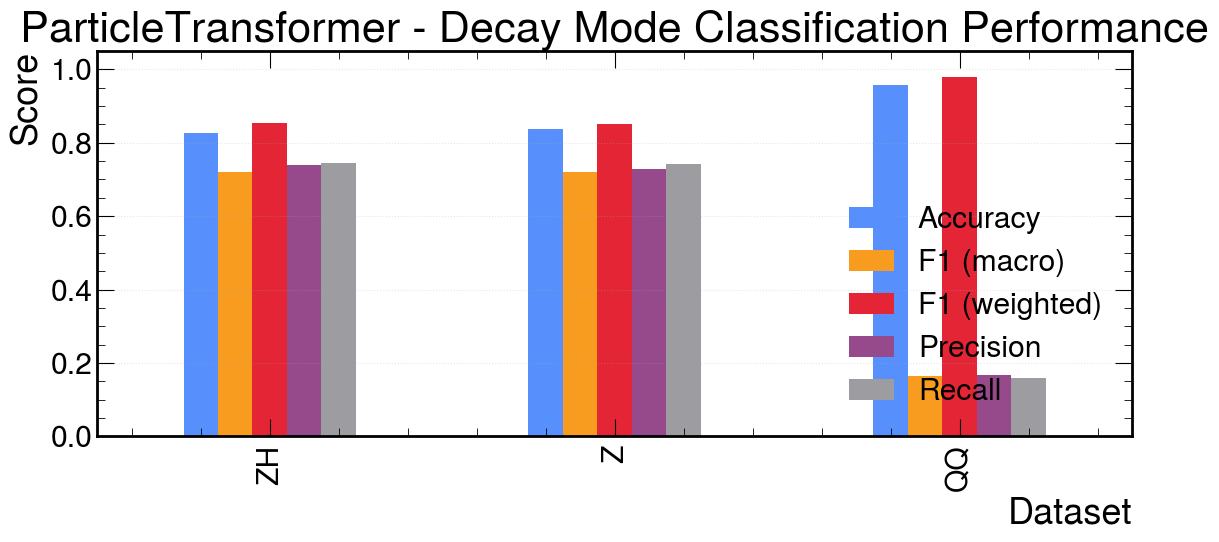

In [33]:
summary_data = {
    'Dataset': ['ZH', 'Z', 'QQ'],
    'Accuracy': [metrics_zh['accuracy'], metrics_z['accuracy'], metrics_qq['accuracy']],
    'F1 (macro)': [metrics_zh['f1_macro'], metrics_z['f1_macro'], metrics_qq['f1_macro']],
    'F1 (weighted)': [metrics_zh['f1_weighted'], metrics_z['f1_weighted'], metrics_qq['f1_weighted']],
    'Precision': [metrics_zh['precision_macro'], metrics_z['precision_macro'], metrics_qq['precision_macro']],
    'Recall': [metrics_zh['recall_macro'], metrics_z['recall_macro'], metrics_qq['recall_macro']]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("Overall Performance Summary")
print("="*80)
print(summary_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
summary_df.set_index('Dataset')[['Accuracy', 'F1 (macro)', 'F1 (weighted)', 'Precision', 'Recall']].plot(kind='bar', ax=ax)
ax.set_ylabel('Score')
ax.set_title('ParticleTransformer - Decay Mode Classification Performance')
ax.legend(loc='lower right')
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()